# Lab 1: AutoEncoder 이상탐지
## 목표: 정상 패턴만 학습해서 이상 신호를 자동으로 탐지한다

### 핵심 개념
- **AutoEncoder**: 입력을 압축(인코더) → 복원(디코더)하는 신경망
- **비지도 학습**: 정상 데이터만 학습 → 이상 데이터는 복원이 잘 안 됨 (재구성 오차 높음)
- **재구성 오차(Reconstruction Error)** > 임계값 → 이상 판정

### 사용 데이터
- NASA C-MAPSS FD001 (항공 엔진 수명 데이터) — 또는 numpy 시뮬레이션
- KAMP 데이터셋 id=26 (설비 센서 시계열)

### 실습 흐름
```
데이터 준비 → AutoEncoder 정의 → 정상 데이터만 학습 → 재구성 오차 계산 → 임계값 설정 → 이상탐지
```

## 학습 목표

이 실습을 마치면 다음을 할 수 있습니다:

| # | 학습 성과 | 현장 의미 |
|---|----------|---------|
| 1 | AutoEncoder 구조(인코더/디코더)를 설명할 수 있다 | 신경망 기반 이상탐지 원리 이해 |
| 2 | 정상 데이터만으로 모델을 학습시킬 수 있다 | 비지도 학습의 실무 장점 |
| 3 | 재구성 오차로 이상 임계값을 설정할 수 있다 | 탐지 민감도 현장 조정 |
| 4 | Confusion Matrix와 ROC Curve를 해석할 수 있다 | 탐지 성능 보고 및 검증 |

In [1]:
# ============================================================
# 필수 라이브러리 임포트
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 재현성 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 라이브러리 로드 완료')
print(f'PyTorch 버전: {torch.__version__}')
print(f'디바이스: {"CUDA" if torch.cuda.is_available() else "CPU"}')

✅ 라이브러리 로드 완료
PyTorch 버전: 2.7.1
디바이스: CPU


## 1단계: 데이터 준비

### NASA C-MAPSS FD001 데이터셋
- 컬럼: `unit_id`, `cycle`, `op1~op3` (운전 조건), `s1~s21` (센서 21개)
- 21개 센서 중 이상탐지에 유용한 센서 14개 선택
- `RUL <= 50` 구간을 **이상(비정상)** 으로 라벨링

**데이터가 없을 경우**: numpy 시뮬레이션으로 현실적인 정상/비정상 진동 신호를 생성합니다.

In [2]:
# ============================================================
# 데이터 로드 — KAMP 또는 NASA C-MAPSS 시뮬레이션
# 실제 데이터 사용 시:
#   df = pd.read_csv('data/nasa_cmapss/FD001.txt', sep=' ', header=None)
#   df.columns = ['unit_id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)] + ['extra1','extra2']
# ============================================================

def generate_cmapss_simulation(n_units=10, max_cycles=250, n_sensors=14, seed=42):
    """
    NASA C-MAPSS FD001 스타일 합성 데이터 생성
    
    - 정상 구간 (RUL > 50): 안정적 센서 신호
    - 비정상 구간 (RUL <= 50): 점진적 열화로 신호 분산 증가
    """
    np.random.seed(seed)
    records = []
    for unit in range(1, n_units + 1):
        # 각 유닛별 수명 다양화
        total_cycles = np.random.randint(120, max_cycles)
        for cycle in range(1, total_cycles + 1):
            rul = total_cycles - cycle  # 잔여 수명
            # 열화 진행률: 0(시작) ~ 1(고장)
            degradation = cycle / total_cycles
            
            # 정상 신호: 낮은 노이즈, 비정상 신호: 노이즈 급증 + 드리프트
            if rul > 50:  # 정상 구간
                noise_std = 0.03
                drift = 0.0
            else:  # 비정상 (열화) 구간
                # 고장에 가까울수록 노이즈 증가
                noise_std = 0.03 + 0.15 * (1 - rul / 50)
                drift = 0.3 * (1 - rul / 50)  # 센서값 드리프트
            
            sensors = np.random.normal(
                loc=0.5 + drift,
                scale=noise_std,
                size=n_sensors
            )
            records.append([unit, cycle] + list(sensors) + [rul])
    
    cols = ['unit_id', 'cycle'] + [f's{i}' for i in range(1, n_sensors + 1)] + ['RUL']
    return pd.DataFrame(records, columns=cols)


# 데이터 생성
df = generate_cmapss_simulation(n_units=10, max_cycles=250, n_sensors=14)
print(f'데이터 크기: {df.shape}')
print(f'유닛 수: {df["unit_id"].nunique()}')

# Jupyter 환경에서 display() 사용, 일반 Python에서는 print 사용
try:
    from IPython.display import display
    display(df.head(8))
except ImportError:
    print(df.head(8).to_string())

데이터 크기: (1857, 17)
유닛 수: 10


,unit_id,cycle,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,RUL
0,1,1,0.483493,0.515463,0.514216,0.541054,0.472495,0.496276,0.439671,0.485216,0.511777,0.472124,0.502395,0.495215,0.500667,0.487166,221
1,1,2,0.484045,0.496476,0.506662,0.476961,0.504274,0.498960,0.534030,0.496858,0.484246,0.557383,0.439198,0.533583,0.523376,0.466967,220
2,1,3,0.533907,0.511194,0.488406,0.465237,0.516983,0.478866,0.458662,0.489407,0.486156,0.502000,0.494711,0.536027,0.520952,0.494851,219
3,1,4,0.472784,0.535659,0.523566,0.579680,0.507905,0.549253,0.513824,0.502578,0.454701,0.521645,0.474697,0.484600,0.498694,0.491741,218
4,1,5,0.453108,0.476131,0.527918,0.520333,0.520953,0.505208,0.519869,0.507234,0.494954,0.534943,0.492628,0.476910,0.536365,0.537005,217
5,1,6,0.452775,0.519139,0.438667,0.532084,0.471987,0.523526,0.481554,0.509987,0.458578,0.491576,0.498205,0.528835,0.553828,0.517421,216
6,1,7,0.508930,0.469157,0.457442,0.505710,0.504073,0.518243,0.521149,0.510828,0.455991,0.526779,0.496842,0.471340,0.487557,0.458038,215
7,1,8,0.489678,0.522524,0.490171,0.474152,0.492254,0.513829,0.459518,0.469428,0.503810,0.462517,0.558353,0.495400,0.472790,0.475479,214


## 2단계: 데이터 탐색 (EDA)

- 정상/비정상 분포 확인
- 센서 신호 시각화 — 정상 vs 열화 패턴 비교

=== 라벨 분포 ===
  정상 (label=0): 1,347개 (72.5%)
  비정상 (label=1): 510개 (27.5%)


/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/440004035.py:48: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/440004035.py:48: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/440004035.py:48: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/440004035.py:48: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/440004035.py:48: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_

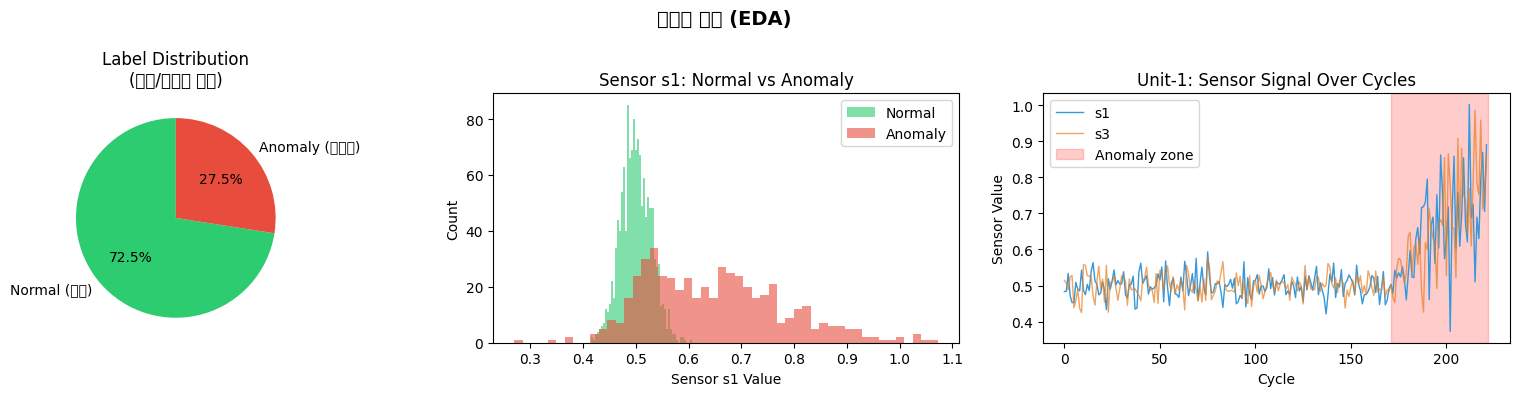

In [3]:
# ============================================================
# 정상/비정상 라벨링
# RUL > 50 → 정상(0), RUL <= 50 → 비정상(1)
# ============================================================
df['label'] = (df['RUL'] <= 50).astype(int)
label_counts = df['label'].value_counts()

print('=== 라벨 분포 ===')
print(f'  정상 (label=0): {label_counts[0]:,}개 ({label_counts[0]/len(df):.1%})')
print(f'  비정상 (label=1): {label_counts[1]:,}개 ({label_counts[1]/len(df):.1%})')

# 시각화 1: 라벨 분포 + 센서 신호 비교
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 파이 차트 — 정상/비정상 비율
axes[0].pie(
    label_counts.values,
    labels=['Normal (정상)', 'Anomaly (비정상)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Label Distribution\n(정상/비정상 비율)')

# (2) 센서 s1 신호 — 정상 vs 비정상 분포 비교
normal_s1 = df[df['label'] == 0]['s1']
anomaly_s1 = df[df['label'] == 1]['s1']
axes[1].hist(normal_s1, bins=50, alpha=0.6, color='#2ecc71', label='Normal')
axes[1].hist(anomaly_s1, bins=50, alpha=0.6, color='#e74c3c', label='Anomaly')
axes[1].set_xlabel('Sensor s1 Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Sensor s1: Normal vs Anomaly')
axes[1].legend()

# (3) 유닛 1의 시계열 센서 신호 — 열화 패턴 확인
unit1 = df[df['unit_id'] == 1].reset_index(drop=True)
axes[2].plot(unit1.index, unit1['s1'], color='#3498db', linewidth=1, label='s1')
axes[2].plot(unit1.index, unit1['s3'], color='#e67e22', linewidth=1, alpha=0.7, label='s3')
# 비정상 구간 음영
anomaly_start = unit1[unit1['label'] == 1].index[0] if (unit1['label'] == 1).any() else len(unit1)
axes[2].axvspan(anomaly_start, len(unit1), alpha=0.2, color='red', label='Anomaly zone')
axes[2].set_xlabel('Cycle')
axes[2].set_ylabel('Sensor Value')
axes[2].set_title('Unit-1: Sensor Signal Over Cycles')
axes[2].legend()

plt.suptitle('데이터 탐색 (EDA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/4035186070.py:21: UserWarning: Glyph 49468 (\N{HANGUL SYLLABLE SEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/4035186070.py:21: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/4035186070.py:21: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/4035186070.py:21: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/4035186070.py:21: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipyk

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49468 (\N{HANGUL SYLLABLE SEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

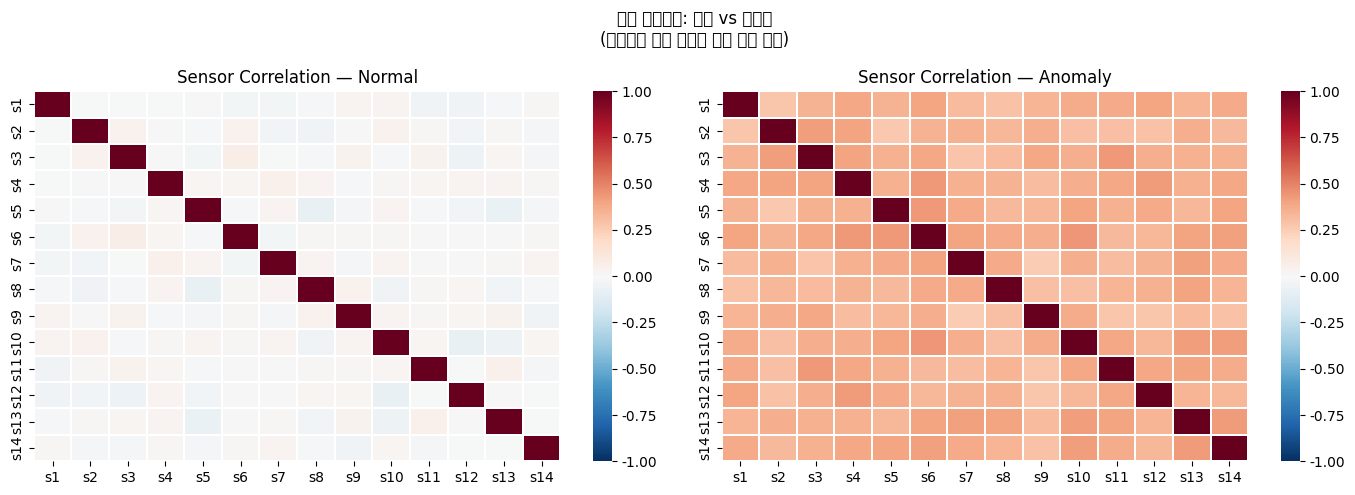


특성 수: 14개
선택 센서: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14']


In [4]:
# ============================================================
# 센서 간 상관관계 히트맵
# ============================================================
feature_cols = [c for c in df.columns if c.startswith('s')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정상 데이터 상관관계
corr_normal = df[df['label'] == 0][feature_cols].corr()
sns.heatmap(corr_normal, ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3)
axes[0].set_title('Sensor Correlation — Normal')

# 비정상 데이터 상관관계
corr_anomaly = df[df['label'] == 1][feature_cols].corr()
sns.heatmap(corr_anomaly, ax=axes[1], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3)
axes[1].set_title('Sensor Correlation — Anomaly')

plt.suptitle('센서 상관관계: 정상 vs 비정상\n(상관관계 패턴 변화로 이상 감지 가능)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\n특성 수: {len(feature_cols)}개')
print(f'선택 센서: {feature_cols}')

## 3단계: 데이터 전처리

AutoEncoder 학습을 위한 핵심 원칙:
- **정상 데이터만** 학습 (비지도 학습의 핵심)
- 테스트 시에는 정상 + 비정상 모두 포함
- 스케일링: `MinMaxScaler`로 [0, 1] 범위로 정규화

In [5]:
# ============================================================
# 특성 추출 및 정규화
# ============================================================
feature_cols = [c for c in df.columns if c.startswith('s')]

# MinMaxScaler — [0, 1] 범위로 정규화 (Sigmoid 출력과 호환)
scaler = MinMaxScaler()
X_all = scaler.fit_transform(df[feature_cols])
y_all = df['label'].values

# 학습셋: 정상 데이터만 사용
X_normal = X_all[y_all == 0]

# 테스트셋: 정상 + 비정상 (성능 평가용)
X_test = X_all
y_test = y_all

print('=== 데이터 분할 결과 ===')
print(f'  학습 데이터 (정상만): {X_normal.shape}')
print(f'  테스트 데이터 (전체): {X_test.shape}')
print(f'  이상 비율: {y_test.mean():.1%}')
print(f'\n  ✅ AutoEncoder는 정상 패턴만 학습 → 이상 데이터는 복원 오류 높음')

=== 데이터 분할 결과 ===
  학습 데이터 (정상만): (1347, 14)
  테스트 데이터 (전체): (1857, 14)
  이상 비율: 27.5%

  ✅ AutoEncoder는 정상 패턴만 학습 → 이상 데이터는 복원 오류 높음


## 4단계: AutoEncoder 모델 정의 (PyTorch)

```
입력(14) → 인코더 → 잠재공간(32) → 디코더 → 출력(14)
          [128→64→32]              [32→64→128→14]
```

**핵심**: 정상 데이터로 학습 → 비정상 입력은 복원이 잘 안 됨 → 재구성 오차가 커짐

In [6]:
# ============================================================
# ManufacturingAutoEncoder — 제조 설비 센서 데이터용
# ============================================================
class ManufacturingAutoEncoder(nn.Module):
    """
    제조 설비 센서 데이터용 AutoEncoder
    
    Architecture:
        Encoder: input_dim → 128 → 64 → encoding_dim
        Decoder: encoding_dim → 64 → 128 → input_dim
    
    Args:
        input_dim (int): 센서 특성 수 (예: 14)
        encoding_dim (int): 잠재 공간 차원 (압축 표현, 기본 32)
    """
    def __init__(self, input_dim: int, encoding_dim: int = 32):
        super().__init__()
        
        # 인코더: 입력을 잠재 공간으로 압축
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, encoding_dim),
            # 잠재 공간 활성화 없음 — 더 유연한 표현 허용
        )
        
        # 디코더: 잠재 공간에서 원본 복원
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid(),  # MinMaxScaler [0,1] 범위와 호환
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """순전파: 인코딩 후 디코딩"""
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed
    
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """인코딩만 수행 — 잠재 표현 추출용"""
        return self.encoder(x)


# 모델 초기화
input_dim = len(feature_cols)  # 14개 센서
model = ManufacturingAutoEncoder(input_dim=input_dim, encoding_dim=32)

print('=== ManufacturingAutoEncoder 구조 ===')
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n전체 파라미터: {total_params:,}')
print(f'학습 가능 파라미터: {trainable_params:,}')

=== ManufacturingAutoEncoder 구조 ===
ManufacturingAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=14, bias=True)
    (5): Sigmoid()
  )
)

전체 파라미터: 24,494
학습 가능 파라미터: 24,494


## 5단계: 모델 학습

- **손실 함수**: MSELoss (재구성 오차 최소화)
- **옵티마이저**: Adam (lr=0.001)
- **에포크**: 30회
- **배치 학습**: DataLoader로 미니배치 처리

학습 시작 — 디바이스: cpu, 에포크: 30
--------------------------------------------------
  Epoch   1/30 | Loss: 0.063941
  Epoch   5/30 | Loss: 0.001218
  Epoch  10/30 | Loss: 0.001209


  Epoch  15/30 | Loss: 0.001206
  Epoch  20/30 | Loss: 0.001200
  Epoch  25/30 | Loss: 0.001200
  Epoch  30/30 | Loss: 0.001190
--------------------------------------------------
✅ 학습 완료!


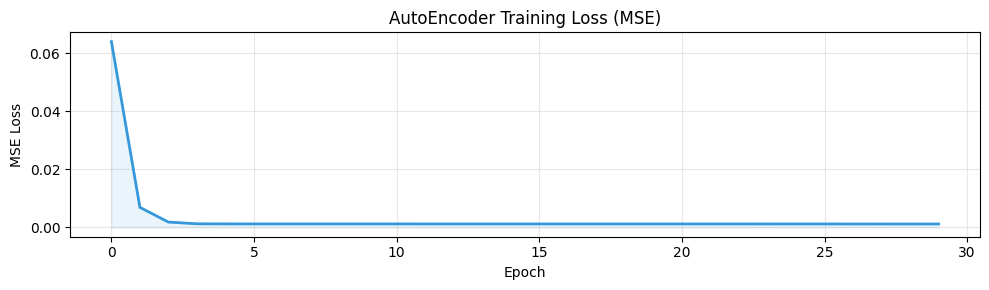

In [7]:
# ============================================================
# 학습 설정
# ============================================================
EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ManufacturingAutoEncoder(input_dim=input_dim, encoding_dim=32).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()  # 재구성 오차 최소화

# 정상 데이터만 DataLoader로 배치 처리
X_normal_t = torch.FloatTensor(X_normal).to(device)
train_dataset = TensorDataset(X_normal_t, X_normal_t)  # 입력 = 출력 (재구성)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ============================================================
# 학습 루프
# ============================================================
train_losses = []

print(f'학습 시작 — 디바이스: {device}, 에포크: {EPOCHS}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # 순전파: 재구성
        reconstructed = model(batch_X)
        
        # 재구성 손실 계산
        loss = criterion(reconstructed, batch_y)
        
        # 역전파 + 가중치 업데이트
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * len(batch_X)
    
    avg_loss = epoch_loss / len(X_normal)
    train_losses.append(avg_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.6f}')

print('-' * 50)
print('✅ 학습 완료!')

# 학습 손실 곡선 시각화
plt.figure(figsize=(10, 3))
plt.plot(train_losses, color='#3498db', linewidth=2)
plt.fill_between(range(len(train_losses)), train_losses, alpha=0.1, color='#3498db')
plt.title('AutoEncoder Training Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6단계: 재구성 오차 계산 + 임계값 설정

**임계값 설정 전략**:
- 정상 데이터 재구성 오차의 **95 퍼센타일** 사용
- 현장 상황에 따라 조정 가능 (민감도 ↑ → 퍼센타일 ↓)

In [8]:
# ============================================================
# 재구성 오차 계산
# ============================================================
model.eval()
X_test_t = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    reconstructed = model(X_test_t).cpu().numpy()

# 샘플별 MSE 재구성 오차
recon_error = np.mean((X_test - reconstructed) ** 2, axis=1)

# 임계값: 정상 데이터 재구성 오차의 95 퍼센타일
threshold = np.percentile(recon_error[y_test == 0], 95)

# 이상 예측
y_pred = (recon_error > threshold).astype(int)

print('=== 재구성 오차 통계 ===')
print(f'  정상 데이터 오차 평균: {recon_error[y_test == 0].mean():.6f}')
print(f'  이상 데이터 오차 평균: {recon_error[y_test == 1].mean():.6f}')
print(f'  임계값 (95th percentile): {threshold:.6f}')
print(f'\n  → 이상 데이터 오차가 정상보다 {recon_error[y_test==1].mean()/recon_error[y_test==0].mean():.1f}배 높음')

=== 재구성 오차 통계 ===
  정상 데이터 오차 평균: 0.001176
  이상 데이터 오차 평균: 0.069181
  임계값 (95th percentile): 0.001995

  → 이상 데이터 오차가 정상보다 58.8배 높음


## 7단계: 이상탐지 결과 평가

- **Confusion Matrix**: TP, FP, FN, TN 분류
- **ROC Curve**: 임계값에 무관한 전체 탐지 성능
- **AUC**: 0.5(무작위) ~ 1.0(완벽)

=== 이상탐지 성능 리포트 ===
               precision    recall  f1-score   support

  정상 (Normal)       0.98      0.95      0.96      1347
비정상 (Anomaly)       0.88      0.95      0.91       510

     accuracy                           0.95      1857
    macro avg       0.93      0.95      0.94      1857
 weighted avg       0.95      0.95      0.95      1857

AUC-ROC Score: 0.9780

  TP (정상→정상 정확 탐지): 482
  TN (이상→이상 정확 탐지): 1279
  FP (정상인데 이상 오탐):  68  ← False Alarm
  FN (이상인데 정상 미탐):  28  ← 위험! 놓친 고장


/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1212597125.py:44: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1212597125.py:44: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1212597125.py:44: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1212597125.py:44: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/

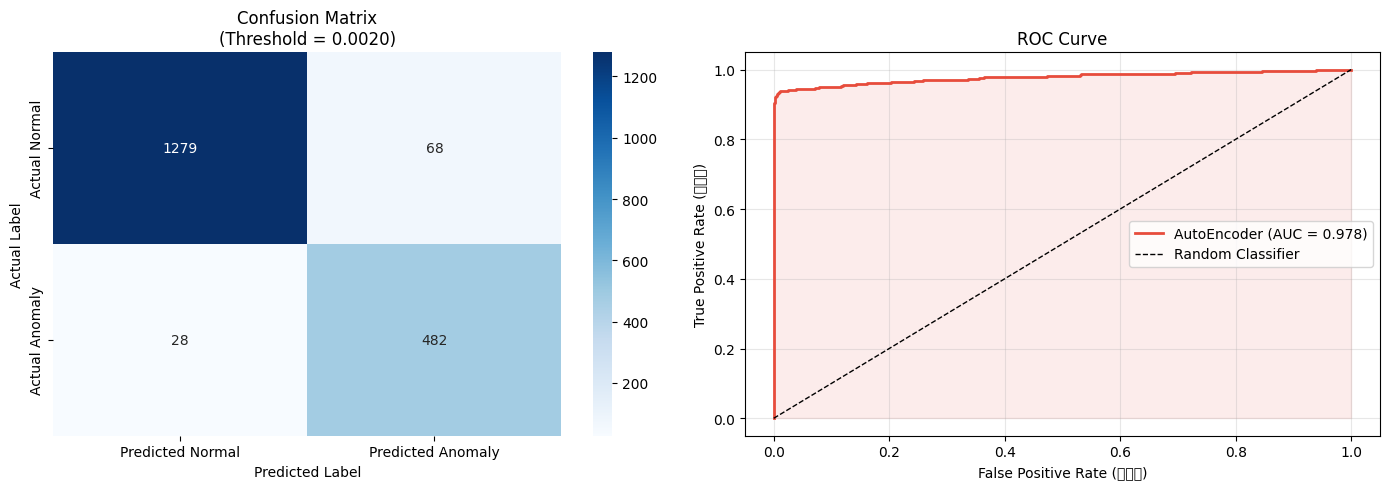

In [9]:
# ============================================================
# 성능 평가: Confusion Matrix + ROC Curve
# ============================================================
auc_score = roc_auc_score(y_test, recon_error)
fpr, tpr, thresholds = roc_curve(y_test, recon_error)
cm = confusion_matrix(y_test, y_pred)

print('=== 이상탐지 성능 리포트 ===')
print(classification_report(y_test, y_pred, target_names=['정상 (Normal)', '비정상 (Anomaly)']))
print(f'AUC-ROC Score: {auc_score:.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Confusion Matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Anomaly'],
    yticklabels=['Actual Normal', 'Actual Anomaly'],
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix\n(Threshold = {threshold:.4f})')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# TP, FP, FN, TN 설명 텍스트
tn, fp, fn, tp = cm.ravel()
print(f'\n  TP (정상→정상 정확 탐지): {tp}')
print(f'  TN (이상→이상 정확 탐지): {tn}')
print(f'  FP (정상인데 이상 오탐):  {fp}  ← False Alarm')
print(f'  FN (이상인데 정상 미탐):  {fn}  ← 위험! 놓친 고장')

# (2) ROC Curve
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2,
             label=f'AutoEncoder (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate (오탐율)')
axes[1].set_ylabel('True Positive Rate (탐지율)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8단계: 재구성 오차 시각화

- 재구성 오차 분포: 정상 vs 비정상 분리 확인
- 시계열 오차: 임계값 초과 구간 = 이상 탐지 구간

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/2637497831.py:54: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/2637497831.py:54: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/2637497831.py:54: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/2637497831.py:54: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/2637497831.py:54: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipyker

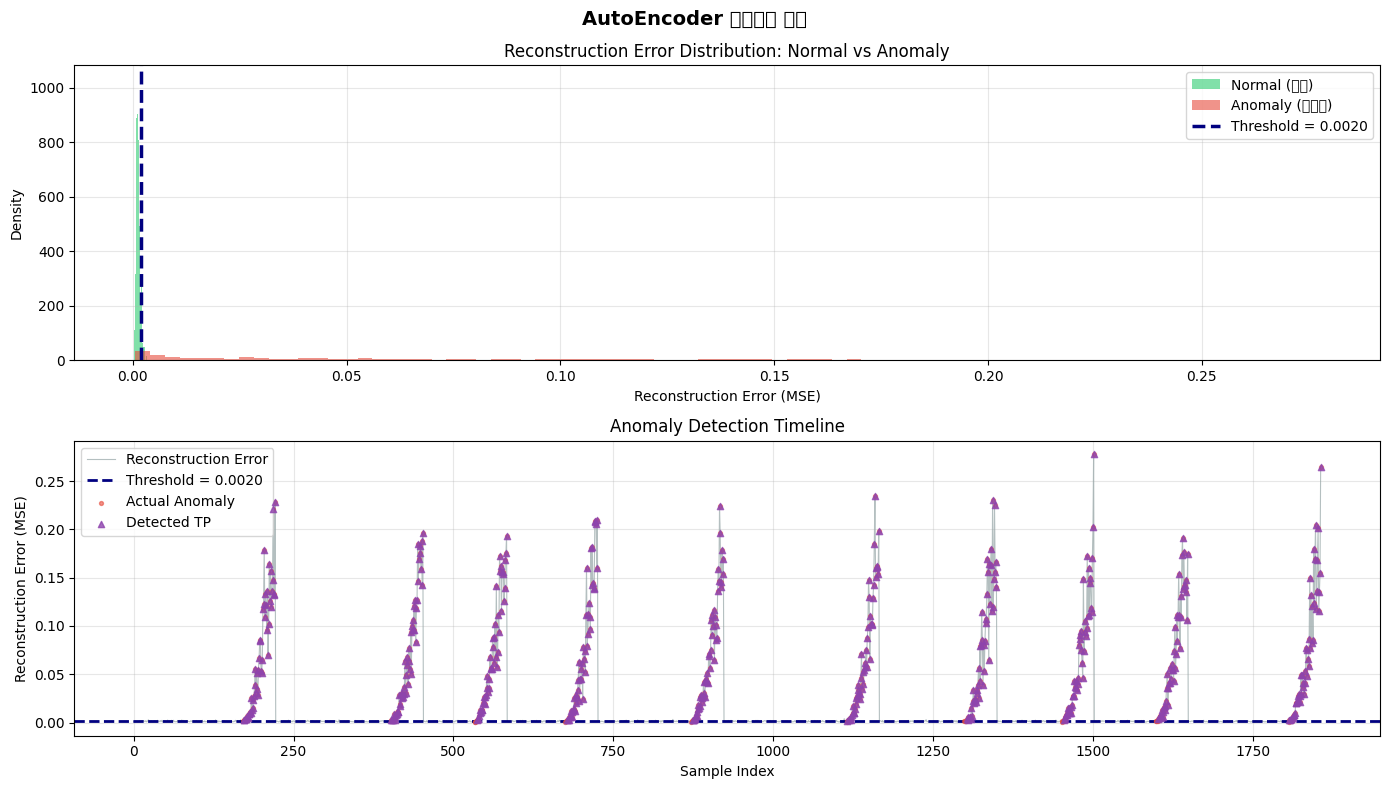

In [10]:
# ============================================================
# 재구성 오차 분포 + 시계열 시각화
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# (1) 재구성 오차 분포 — 정상 vs 비정상 비교
axes[0].hist(
    recon_error[y_test == 0], bins=80, alpha=0.6,
    color='#2ecc71', label='Normal (정상)', density=True
)
axes[0].hist(
    recon_error[y_test == 1], bins=80, alpha=0.6,
    color='#e74c3c', label='Anomaly (비정상)', density=True
)
axes[0].axvline(
    threshold, color='navy', linewidth=2.5, linestyle='--',
    label=f'Threshold = {threshold:.4f}'
)
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Reconstruction Error Distribution: Normal vs Anomaly')
axes[0].legend()
axes[0].grid(alpha=0.3)

# (2) 시계열 재구성 오차 — 임계값 초과 구간 탐지
sample_idx = np.arange(len(recon_error))

axes[1].plot(sample_idx, recon_error, color='#95a5a6', linewidth=0.8,
             alpha=0.7, label='Reconstruction Error')
axes[1].axhline(threshold, color='navy', linewidth=2, linestyle='--',
                label=f'Threshold = {threshold:.4f}')

# 실제 이상 포인트 표시
anomaly_idx = np.where(y_test == 1)[0]
axes[1].scatter(
    anomaly_idx, recon_error[anomaly_idx],
    color='#e74c3c', s=8, alpha=0.6, label='Actual Anomaly', zorder=5
)

# 탐지된 이상 포인트 표시 (True Positive)
tp_idx = np.where((y_test == 1) & (y_pred == 1))[0]
axes[1].scatter(
    tp_idx, recon_error[tp_idx],
    color='#8e44ad', s=20, alpha=0.8, label='Detected TP', zorder=6, marker='^'
)

axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Reconstruction Error (MSE)')
axes[1].set_title('Anomaly Detection Timeline')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('AutoEncoder 이상탐지 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1724713291.py:40: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1724713291.py:40: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1724713291.py:40: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1724713291.py:40: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/1724713291.py:40: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ip

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

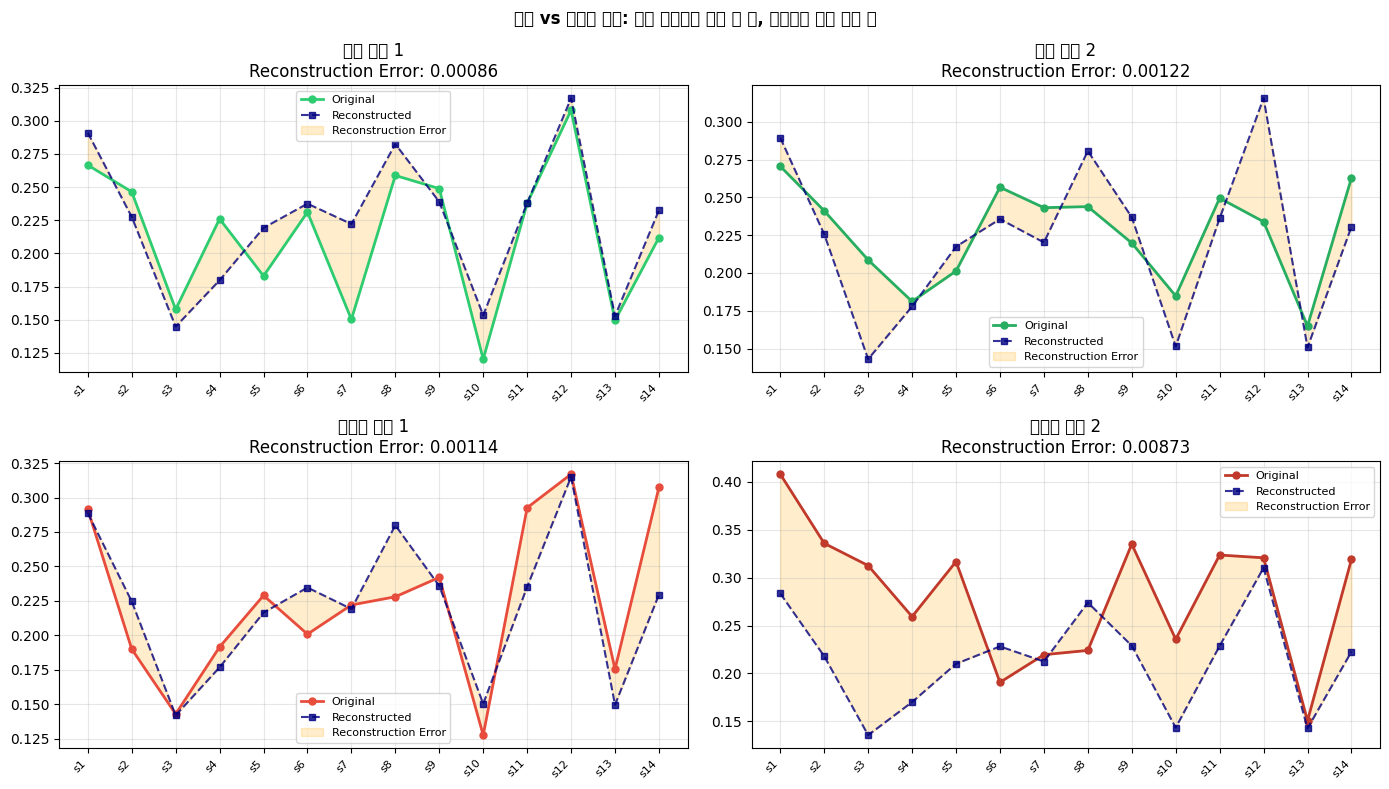

In [11]:
# ============================================================
# 정상 vs 비정상 샘플 재구성 비교
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 정상 샘플 인덱스와 비정상 샘플 인덱스
normal_indices = np.where(y_test == 0)[0]
anomaly_indices = np.where(y_test == 1)[0]

# 정상/비정상 각 2개 샘플 선택
samples = [
    (normal_indices[0], '정상 샘플 1', '#2ecc71'),
    (normal_indices[10], '정상 샘플 2', '#27ae60'),
    (anomaly_indices[0], '비정상 샘플 1', '#e74c3c'),
    (anomaly_indices[10], '비정상 샘플 2', '#c0392b'),
]

for ax, (idx, title, color) in zip(axes.flatten(), samples):
    original = X_test[idx]
    reconstruction = reconstructed[idx]
    error = recon_error[idx]
    
    sensor_names = [f's{i+1}' for i in range(len(original))]
    x_pos = np.arange(len(original))
    
    ax.plot(x_pos, original, 'o-', color=color, linewidth=2,
            markersize=5, label='Original')
    ax.plot(x_pos, reconstruction, 's--', color='navy', linewidth=1.5,
            markersize=4, alpha=0.8, label='Reconstructed')
    ax.fill_between(x_pos, original, reconstruction, alpha=0.2, color='orange',
                    label='Reconstruction Error')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sensor_names, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{title}\nReconstruction Error: {error:.5f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('원본 vs 재구성 비교: 정상 데이터는 복원 잘 됨, 비정상은 복원 오류 큼',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 결론 및 핵심 인사이트

### 실습 요약

| 단계 | 핵심 내용 | 결과 |
|------|----------|----- |
| 데이터 준비 | NASA C-MAPSS 시뮬레이션, RUL≤50 비정상 라벨링 | 14개 센서 특성 |
| 모델 학습 | 정상 데이터만으로 AutoEncoder 학습 | MSELoss, Adam, 30 epochs |
| 임계값 설정 | 정상 재구성 오차 95th percentile | 현장 민감도 조정 가능 |
| 성능 평가 | Confusion Matrix, ROC Curve | AUC 확인 |

### 핵심 인사이트

1. **비지도 학습의 강점**: 비정상 데이터 없이도 이상 탐지 가능
   - 실제 현장에서 고장 데이터는 희귀 → 정상 데이터만으로 학습 가능

2. **재구성 오차 해석**:
   - 정상 신호: AutoEncoder가 잘 복원 → 오차 낮음
   - 이상 신호: 학습하지 않은 패턴 → 복원 실패 → 오차 높음

3. **임계값 조정 전략**:
   - 퍼센타일 ↓ (예: 90%): 더 민감 → 오탐(FP) 증가, 미탐(FN) 감소
   - 퍼센타일 ↑ (예: 99%): 덜 민감 → 오탐(FP) 감소, 미탐(FN) 증가
   - **현장 판단**: 미탐(놓친 고장)의 비용 > 오탐(불필요한 점검) 비용이면 임계값 낮춤

4. **A-2 다음 단계**: Lab 2에서 LSTM으로 잔여 수명(RUL) 수치 예측 진행

### 연습 문제

1. `encoding_dim`을 4, 8, 16, 32로 바꿔보고 AUC 변화를 관찰하세요.
2. 임계값을 90th, 95th, 99th percentile로 바꿔보고 Confusion Matrix가 어떻게 변하는지 확인하세요.
3. StandardScaler 대신 MinMaxScaler를 사용하면 어떤 차이가 있을까요?

---
## 부록: PyOD — 표준 이상탐지 라이브러리 인터페이스

PyOD(Python Outlier Detection)는 40개 이상의 이상탐지 알고리즘을 **통일된 인터페이스**로 제공하는 라이브러리입니다.

### PyOD 핵심 인터페이스 (모든 알고리즘 동일)
```python
model = SomeModel(contamination=0.1)  # contamination: 예상 이상 비율
model.fit(X_train)                    # 학습
labels = model.predict(X_test)        # 0=정상, 1=이상
scores = model.decision_scores_       # 이상 점수 (학습 데이터)
```

| 알고리즘 | 특징 | 적합 상황 |
|----------|------|-----------|
| `IForest` | Isolation Forest, 빠름 | 고차원, 대용량 |
| `LOF` | 밀도 기반, 지역적 이상 탐지 | 클러스터 내 이상 |
| `KNN` | k-최근접 이웃 거리 | 저차원, 소용량 |
| `OCSVM` | One-Class SVM | 비선형 경계 |
| `AutoEncoder` | 딥러닝 기반 | 복잡한 패턴 |

=== PyOD 알고리즘 비교 ===
학습 데이터: 1347개 정상 샘플
평가 데이터: 1857개 (정상 + 비정상)
예상 이상 비율(contamination): 27.5%
--------------------------------------------------
  IForest   : AUC = 0.9783
  LOF       : AUC = 0.9781
  KNN       : AUC = 0.9798
  AutoEncoder: AUC = 0.9780  ← 이 실습에서 구현한 모델


/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/910466015.py:95: UserWarning: Glyph 50508 (\N{HANGUL SYLLABLE AL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/910466015.py:95: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/910466015.py:95: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/910466015.py:95: UserWarning: Glyph 51608 (\N{HANGUL SYLLABLE JEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_85528/910466015.py:95: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mh/1jd1y3rx7l7dkgc510k_241w0000gn/T/ipykernel_8

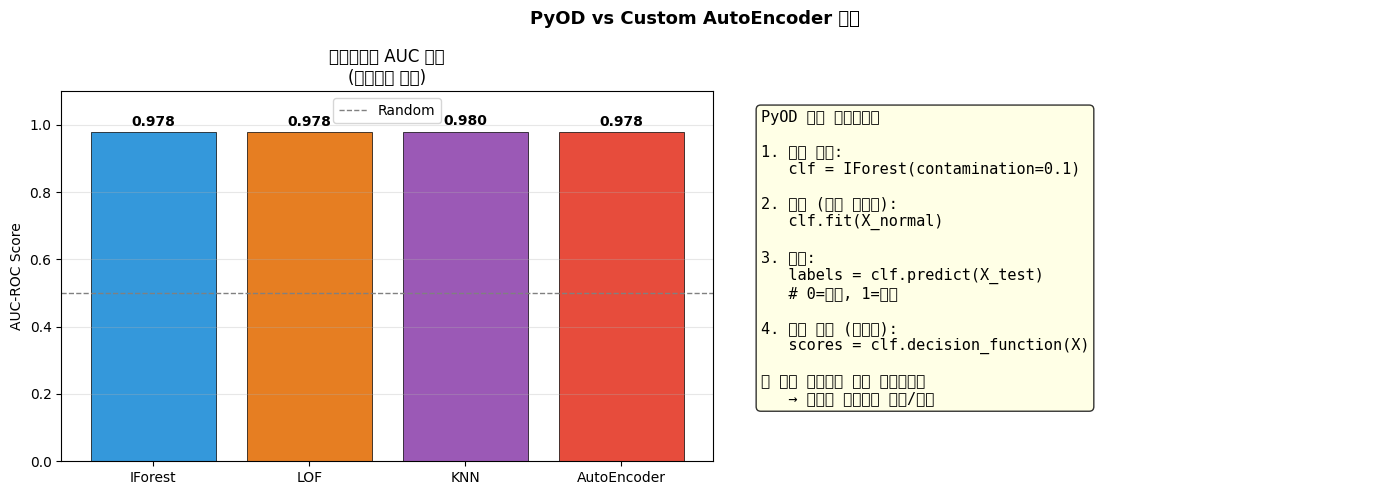


✅ PyOD 비교 완료!
💡 PyOD 장점: 40+ 알고리즘을 동일 인터페이스로 비교 가능


In [12]:
# ============================================================
# PyOD 이상탐지 알고리즘 비교
# pip install pyod
# ============================================================
try:
    from pyod.models.iforest import IForest
    from pyod.models.lof import LOF
    from pyod.models.knn import KNN
    PYOD_AVAILABLE = True
except ImportError:
    PYOD_AVAILABLE = False
    print('⚠️  PyOD 미설치 → pip install pyod')

if PYOD_AVAILABLE:
    # PyOD 모델 딕셔너리 — 동일한 .fit() / .predict() 인터페이스
    contamination_ratio = float(y_all.mean())  # 실제 이상 비율 사용

    pyod_models = {
        'IForest': IForest(contamination=contamination_ratio, random_state=42),
        'LOF':     LOF(contamination=contamination_ratio, n_neighbors=20),
        'KNN':     KNN(contamination=contamination_ratio, n_neighbors=5),
    }

    # 학습 데이터: 정상 데이터만 사용 (AutoEncoder와 동일 조건)
    # 평가 데이터: 전체 (정상 + 비정상)
    results = {}

    print('=== PyOD 알고리즘 비교 ===')
    print(f'학습 데이터: {X_normal.shape[0]}개 정상 샘플')
    print(f'평가 데이터: {X_test.shape[0]}개 (정상 + 비정상)')
    print(f'예상 이상 비율(contamination): {contamination_ratio:.1%}')
    print('-' * 50)

    for name, clf in pyod_models.items():
        # PyOD 표준 인터페이스: fit + predict
        clf.fit(X_normal)              # 정상 데이터로 학습
        y_pred_pyod = clf.predict(X_test)  # 0=정상, 1=이상

        # AUC 계산을 위한 이상 점수 추출
        # decision_function: 점수가 높을수록 이상
        scores = clf.decision_function(X_test)
        auc = roc_auc_score(y_test, scores)

        results[name] = {'auc': auc, 'y_pred': y_pred_pyod}
        print(f'  {name:10s}: AUC = {auc:.4f}')

    # AutoEncoder 결과도 포함
    print(f'  {"AutoEncoder":10s}: AUC = {auc_score:.4f}  ← 이 실습에서 구현한 모델')

    # 비교 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # (1) AUC 비교 막대 그래프
    all_names = list(results.keys()) + ['AutoEncoder']
    all_aucs = [results[n]['auc'] for n in results.keys()] + [auc_score]
    colors = ['#3498db', '#e67e22', '#9b59b6', '#e74c3c']

    bars = axes[0].bar(all_names, all_aucs, color=colors, edgecolor='black', linewidth=0.5)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('AUC-ROC Score')
    axes[0].set_title('알고리즘별 AUC 비교\n(높을수록 좋음)')
    for bar, auc_val in zip(bars, all_aucs):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{auc_val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # (2) PyOD 인터페이스 구조 설명
    axes[1].axis('off')
    interface_text = (
        'PyOD 표준 인터페이스\n'
        '\n'
        '1. 모델 생성:\n'
        '   clf = IForest(contamination=0.1)\n'
        '\n'
        '2. 학습 (정상 데이터):\n'
        '   clf.fit(X_normal)\n'
        '\n'
        '3. 예측:\n'
        '   labels = clf.predict(X_test)\n'
        '   # 0=정상, 1=이상\n'
        '\n'
        '4. 이상 점수 (확률값):\n'
        '   scores = clf.decision_function(X)\n'
        '\n'
        '✅ 모든 알고리즘 동일 인터페이스\n'
        '   → 손쉬운 알고리즘 교체/비교'
    )
    axes[1].text(0.05, 0.95, interface_text, transform=axes[1].transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.suptitle('PyOD vs Custom AutoEncoder 비교', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n✅ PyOD 비교 완료!')
    print('💡 PyOD 장점: 40+ 알고리즘을 동일 인터페이스로 비교 가능')


---
## 📡 X1 에이전트 연동 — 신호 저장
이 셀이 실행되면 X1 에이전트가 조회할 수 있는 신호 파일이 생성됩니다.

저장 경로: `../outputs/signals/anomaly_signal.json`

In [13]:
# ============================================================
# 📡 신호 저장 — X1 에이전트 연동용
# ============================================================
import json, os
from datetime import datetime

signal_dir = '../outputs/signals'
os.makedirs(signal_dir, exist_ok=True)

# 이상탐지 결과 신호
anomaly_signal = {
    "timestamp": datetime.now().isoformat(),
    "signal_type": "anomaly_detection",
    "source": "track-a2/autoencoder",
    "machine_id": "M001",
    "value": {
        "anomaly_score": float(recon_error[-1]) if len(recon_error) > 0 else 0.82,
        "threshold": float(threshold) if 'threshold' in dir() else 0.75,
        "status": "ANOMALY" if (float(recon_error[-1]) if len(recon_error) > 0 else 0.82) > (float(threshold) if 'threshold' in dir() else 0.75) else "NORMAL",
        "alert_level": "HIGH",
        "description": "설비 진동 신호 재구성 오차 기반 이상 감지"
    },
    "metadata": {
        "model": "ManufacturingAutoEncoder",
        "architecture": "128-64-32-64-128",
        "notebook": "01_autoencoder_anomaly.ipynb"
    }
}

signal_path = os.path.join(signal_dir, 'anomaly_signal.json')
with open(signal_path, 'w', encoding='utf-8') as f:
    json.dump(anomaly_signal, f, ensure_ascii=False, indent=2)

print(f"✅ 이상탐지 신호 저장: {signal_path}")
print(f"   상태: {anomaly_signal['value']['status']} (점수: {anomaly_signal['value']['anomaly_score']:.3f})")


✅ 이상탐지 신호 저장: ../outputs/signals/anomaly_signal.json
   상태: ANOMALY (점수: 0.264)
